In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
pd.set_option("display.max_columns", None)

path = "/content/drive/MyDrive/Data/"




orders = pd.read_csv(path + "orders_core.csv")
products = pd.read_csv(path + "products_dataset.csv")
discounts = pd.read_csv(path + "discounts_dataset_clean.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(orders.columns.tolist())

['order_id', 'created_date', 'total_paid', 'state']


In [ ]:
print(products.columns.tolist())

['sku', 'name', 'desc', 'price', 'in_stock', 'type_short', 'categories', 'price_cat', 'brand']


In [ ]:
print(discounts.columns.tolist())

['id_order', 'date', 'sku', 'product_quantity', 'selling_price', 'catalog_price', 'discount_amount', 'discount_pct']


In [ ]:
# Revenue generated by each transaction

discounts["revenue"] = (
    discounts["selling_price"] *
    discounts["product_quantity"]
)

In [ ]:
df = discounts.merge(
    products[
        ["sku",
         "categories",
         "brand",
         "price_cat"]
    ],
    on="sku",
    how="left"
)

In [ ]:
df.head()

,id_order,date,sku,product_quantity,selling_price,catalog_price,discount_amount,discount_pct,revenue,categories,brand,price_cat
0,299545,2017-01-01 01:46:16,OWC0100,1,47.49,60.99,13.50,22.13,47.49,Adapters,OWC,D
1,299546,2017-01-01 01:50:34,IOT0014,1,18.99,22.95,3.96,17.25,18.99,iPhone Stands,iOttie,E
2,295347,2017-01-01 01:54:11,APP0700,1,72.19,89.00,16.81,18.89,72.19,Chargers,Apple,D
3,299556,2017-01-01 02:20:14,CRU0039-A,1,60.90,76.99,16.09,20.90,60.90,OPEN,Crucial,D
4,299561,2017-01-01 02:38:50,PEB0015,1,142.49,299.99,157.50,52.50,142.49,OTHERS,Pebble,C


In [ ]:
df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.to_period("M").astype(str)

In [ ]:
monthly = (
    df.groupby("month")
      .agg(
          Revenue=("revenue", "sum"),
          Average_Discount=("discount_pct", "mean")
      )
      .reset_index()
)

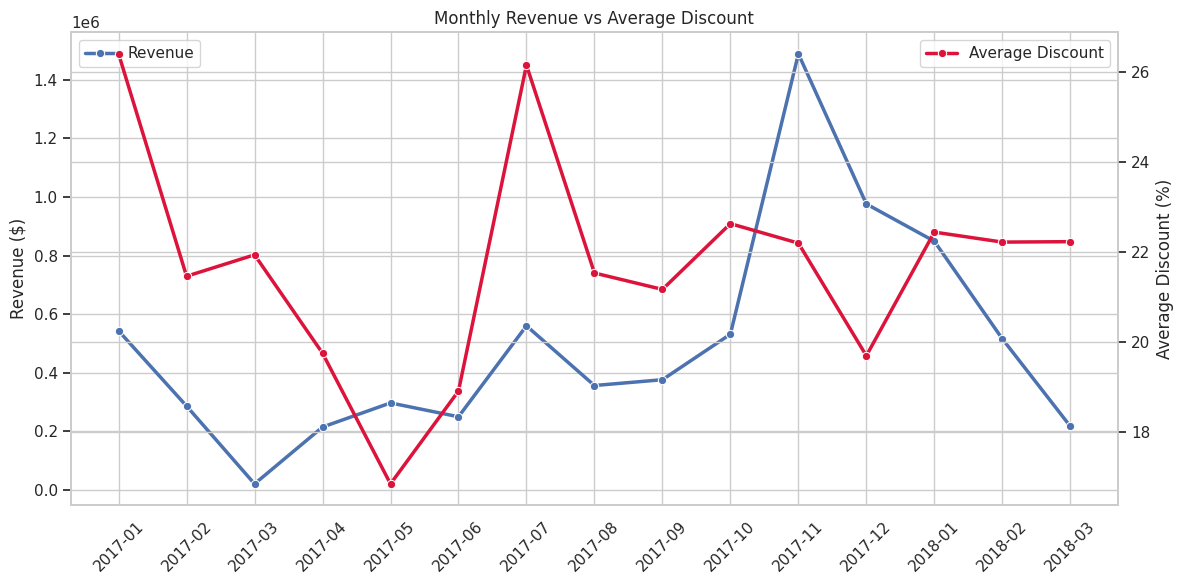

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(
    data=monthly,
    x="month",
    y="Revenue",
    marker="o",
    linewidth=2.5,
    ax=ax1,
    label="Revenue"
)

ax1.set_ylabel("Revenue ($)")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

sns.lineplot(
    data=monthly,
    x="month",
    y="Average_Discount",
    marker="o",
    linewidth=2.5,
    color="crimson",
    ax=ax2,
    label="Average Discount"
)

ax2.set_ylabel("Average Discount (%)")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Monthly Revenue vs Average Discount")
plt.tight_layout()
plt.show()

These findings suggest that increasing discounts alone is not sufficient to drive higher revenue

In [ ]:
discount_bins = [0, 10, 20, 30, 40, 50, 100]

labels = [
    "0–10%",
    "10–20%",
    "20–30%",
    "30–40%",
    "40–50%",
    "50%+"
]

df["discount_group"] = pd.cut(
    df["discount_pct"],
    bins=discount_bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
sales_by_discount = (
    df.groupby("discount_group", observed=False)
      .agg(
          Avg_Quantity=("product_quantity", "mean"),
          Transactions=("id_order", "count")
      )
      .reset_index()
)

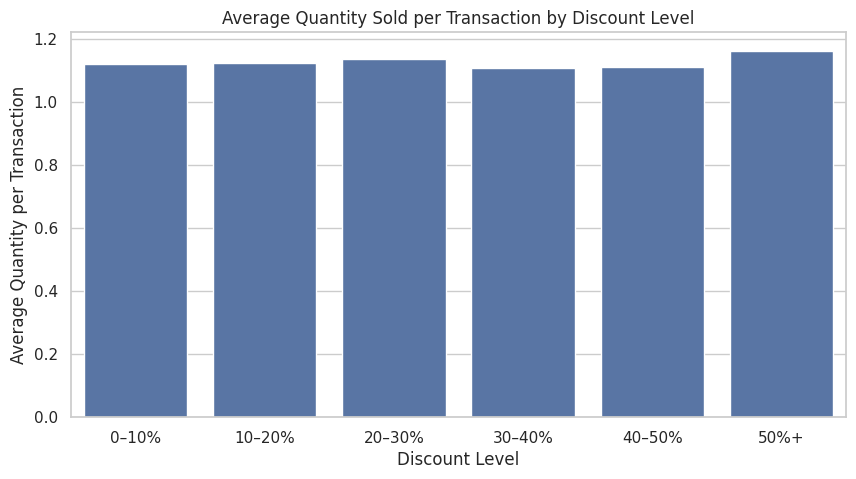

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=sales_by_discount,
    x="discount_group",
    y="Avg_Quantity",
    color="#4C72B0"
)

plt.title("Average Quantity Sold per Transaction by Discount Level")
plt.xlabel("Discount Level")
plt.ylabel("Average Quantity per Transaction")

plt.show()

In [ ]:
revenue_by_discount = (
    df.groupby("discount_group", observed=False)
      .agg(
          Average_Revenue=("revenue", "mean"),
          Transactions=("id_order", "count")
      )
      .reset_index()
)

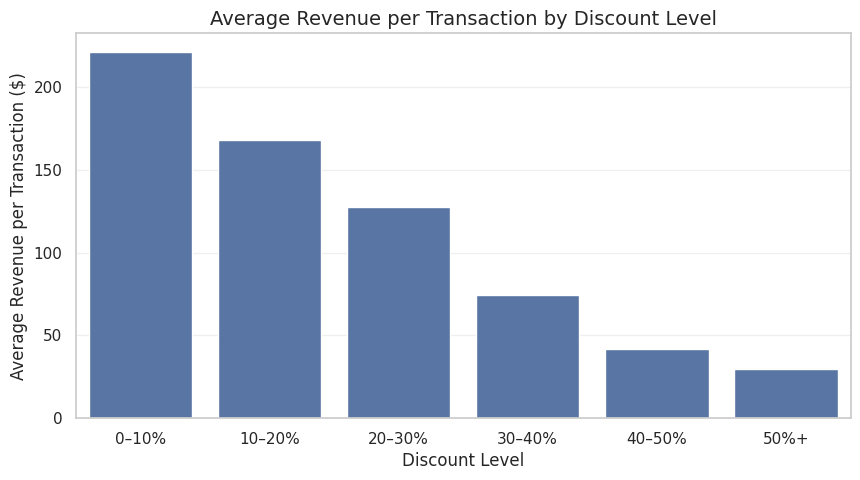

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=revenue_by_discount,
    x="discount_group",
    y="Average_Revenue",
    color="#4C72B0"
)

plt.title("Average Revenue per Transaction by Discount Level", fontsize=14)
plt.xlabel("Discount Level")
plt.ylabel("Average Revenue per Transaction ($)")

plt.grid(axis="y", alpha=0.3)

plt.show()

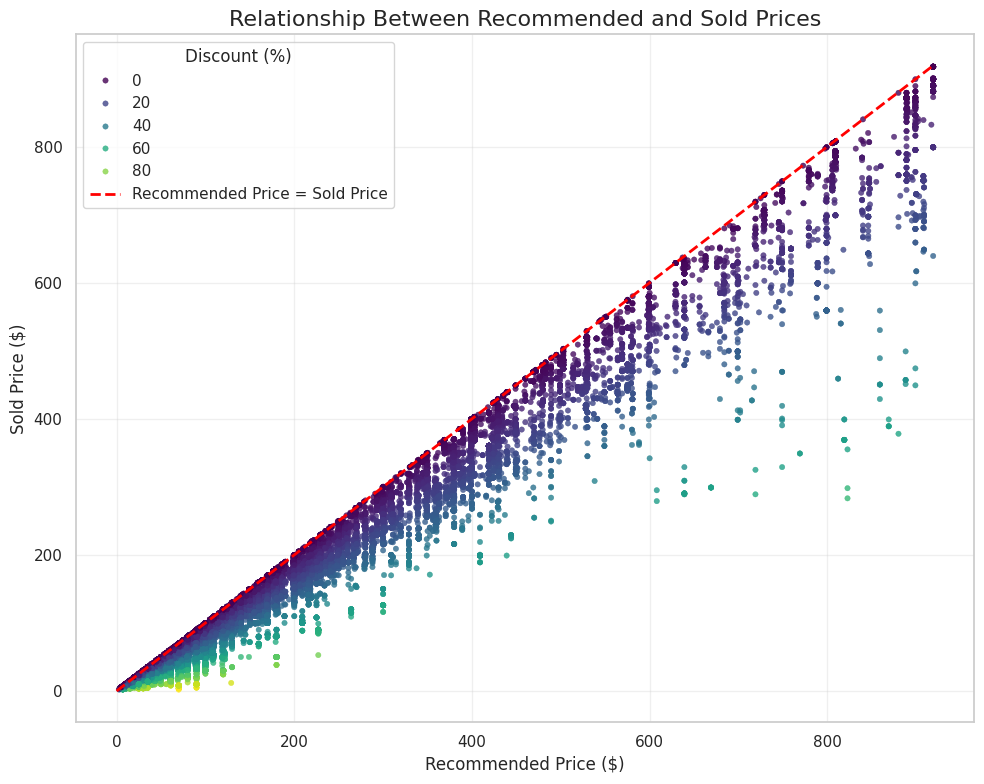

In [ ]:
# Remove extreme outliers (top 1%)
limit = df["catalog_price"].quantile(0.99)

plot_df = df[df["catalog_price"] <= limit]

plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    data=plot_df,
    x="catalog_price",
    y="selling_price",
    hue="discount_pct",
    palette="viridis",
    alpha=0.8,
    s=15,
    edgecolor=None
)

# Reference line (no discount)
max_price = max(
    plot_df["catalog_price"].max(),
    plot_df["selling_price"].max()
)

plt.plot(
    [0, max_price],
    [0, max_price],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Recommended Price = Sold Price"
)

plt.title("Relationship Between Recommended and Sold Prices", fontsize=16)
plt.xlabel("Recommended Price ($)", fontsize=12)
plt.ylabel("Sold Price ($)", fontsize=12)

plt.legend(title="Discount (%)", loc="upper left")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()